# BTC/ETH LOB Pipeline — v4

**Fixes from v3:**

| Problem (v3) | Fix (v4) |
|---|---|
| `classic_factor_cols` defined in separate notebook — v3 file incomplete | Classic factor cell now included inline |
| `StandardScaler` before PCA was commented out | Restored: `StandardScaler` fitted on train only before PCA |
| Market features exported raw (spread, vol, momentum — very small scale) | Rolling Z-score applied to market features |
| Classic factors exported raw (Amihud ~1e-9, OFI ~thousands) | Rolling Z-score applied to classic factors |
| `min_periods=1` gives unreliable normalization in first rows | Changed to `min_periods=60` |
| `classic_factor_cols` used but never defined in v3 | Defined in dedicated cell (Step 4) |

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# ==========================================
# 1. Download and Load Data
# ==========================================
print("=" * 50)
print("1. DOWNLOAD AND LOAD DATA")
print("=" * 50)

dataset_path = kagglehub.dataset_download(
    "martinsn/high-frequency-crypto-limit-order-book-data")
print(f"Dataset path: {dataset_path}")

btc = pd.read_csv(os.path.join(dataset_path, 'BTC_1sec.csv'), nrows=100000)
eth = pd.read_csv(os.path.join(dataset_path, 'ETH_1sec.csv'), nrows=100000)
print(f"BTC shape: {btc.shape}")
print(f"ETH shape: {eth.shape}")


1. DOWNLOAD AND LOAD DATA
Using Colab cache for faster access to the 'high-frequency-crypto-limit-order-book-data' dataset.
Dataset path: /kaggle/input/high-frequency-crypto-limit-order-book-data
BTC shape: (100000, 156)
ETH shape: (100000, 156)


In [2]:
# ==========================================
# 2. Time Alignment
# ==========================================
print("\n" + "=" * 50)
print("2. TIME ALIGNMENT")
print("=" * 50)

btc['system_time'] = pd.to_datetime(btc['system_time'], utc=True)
eth['system_time'] = pd.to_datetime(eth['system_time'], utc=True)
btc['time_key'] = btc['system_time'].dt.floor('s')
eth['time_key'] = eth['system_time'].dt.floor('s')

print(f"BTC time range: {btc['time_key'].min()} -> {btc['time_key'].max()}")
print(f"ETH time range: {eth['time_key'].min()} -> {eth['time_key'].max()}")

eth_slim = eth[['time_key', 'midpoint', 'spread',
                 'bids_notional_0', 'asks_notional_0']].copy()
eth_slim = eth_slim.rename(columns={
    'midpoint':        'eth_midpoint',
    'spread':          'eth_spread',
    'bids_notional_0': 'eth_bids_notional_0',
    'asks_notional_0': 'eth_asks_notional_0',
})

df = pd.merge(btc, eth_slim, on='time_key', how='inner')
df = df.drop(columns=['time_key', 'Unnamed: 0']).reset_index(drop=True)
df = df.set_index('system_time')
print(f"After merge: {df.shape}  ({len(df):,} rows retained)")



2. TIME ALIGNMENT
BTC time range: 2021-04-07 11:32:42+00:00 -> 2021-04-08 15:19:54+00:00
ETH time range: 2021-04-07 11:32:50+00:00 -> 2021-04-08 15:19:46+00:00
After merge: (99972, 158)  (99,972 rows retained)


In [3]:
# ==========================================
# 3. Feature Engineering
# ==========================================
print("\n" + "=" * 50)
print("3. FEATURE ENGINEERING")
print("=" * 50)

window_short       = 10
window_long        = 60
prediction_horizon = 10
label_threshold    = 0.00015

df['mid_price']  = df['midpoint']
df['log_return'] = np.log(df['mid_price'] / df['mid_price'].shift(1))

# ── BTC market features ──────────────────────────────────────
df['btc_oimb_1']         = ((df['bids_notional_0'] - df['asks_notional_0']) /
                             (df['bids_notional_0'] + df['asks_notional_0'] + 1e-8))
df['btc_volatility_10s'] = df['log_return'].rolling(window_short).std()
df['btc_volatility_60s'] = df['log_return'].rolling(window_long).std()
df['btc_momentum_10s']   = df['log_return'].rolling(window_short).sum()
df['btc_momentum_60s']   = df['log_return'].rolling(window_long).sum()

# ── ETH cross-asset features ─────────────────────────────────
df['eth_log_return']     = np.log(df['eth_midpoint'] / df['eth_midpoint'].shift(1))
df['eth_oimb_1']         = ((df['eth_bids_notional_0'] - df['eth_asks_notional_0']) /
                             (df['eth_bids_notional_0'] + df['eth_asks_notional_0'] + 1e-8))
df['eth_volatility_10s'] = df['eth_log_return'].rolling(window_short).std()
df['eth_volatility_60s'] = df['eth_log_return'].rolling(window_long).std()
df['eth_momentum_10s']   = df['eth_log_return'].rolling(window_short).sum()
df['eth_momentum_60s']   = df['eth_log_return'].rolling(window_long).sum()

# ── BTC-ETH cross features ───────────────────────────────────
df['btc_eth_momentum_diff_10s'] = df['btc_momentum_10s'] - df['eth_momentum_10s']
df['btc_eth_momentum_diff_60s'] = df['btc_momentum_60s'] - df['eth_momentum_60s']
df['btc_eth_vol_ratio_10s']     = (df['btc_volatility_10s'] /
                                    (df['eth_volatility_10s'] + 1e-8))

# ── Labels ───────────────────────────────────────────────────
df['future_return'] = ((df['mid_price'].shift(-prediction_horizon) - df['mid_price'])
                        / df['mid_price'])
df['label'] = np.select(
    [df['future_return'] >  label_threshold,
     df['future_return'] < -label_threshold],
    [1, -1], default=0
)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# ── Feature column lists ─────────────────────────────────────
lob_features = []
for i in range(15):
    lob_features.extend([f'bids_distance_{i}', f'asks_distance_{i}',
                          f'bids_notional_{i}', f'asks_notional_{i}'])

market_state_cols = [
    'spread',              'btc_oimb_1',
    'btc_volatility_10s',  'btc_volatility_60s',
    'btc_momentum_10s',    'btc_momentum_60s',
    'eth_spread',          'eth_oimb_1',
    'eth_volatility_10s',  'eth_volatility_60s',
    'eth_momentum_10s',    'eth_momentum_60s',
    'btc_eth_momentum_diff_10s',
    'btc_eth_momentum_diff_60s',
    'btc_eth_vol_ratio_10s',
]

print(f"Shape after dropna: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts().sort_index().to_string()}")
print(f"\nLOB features   : {len(lob_features)}")
print(f"Market features: {len(market_state_cols)}")



3. FEATURE ENGINEERING
Shape after dropna: (99902, 176)
Label distribution:
label
-1    21562
 0    56846
 1    21494

LOB features   : 60
Market features: 15


In [4]:
# ==========================================
# 4. Classic LOB Factors (Academic Literature)
# ==========================================
# v4 fix: this cell was MISSING from BTC_ETH_pipeline_v3.ipynb.
# classic_factor_cols was used in the export cell but never defined,
# meaning v3 only worked if session state was inherited from a prior run.

print("\n" + "=" * 50)
print("4. CLASSIC LOB FACTORS")
print("=" * 50)

eps = 1e-8

# ── Factor 1: Queue Imbalance (Cont, Kukanov & Stoikov 2014) ─────────────────
rho    = 0.5
levels = 5
bid_cols = [f'bids_notional_{i}' for i in range(levels)]
ask_cols = [f'asks_notional_{i}' for i in range(levels)]
weights  = np.exp(-rho * np.arange(levels))
weights /= weights.sum()
bid_mat  = df[bid_cols].values
ask_mat  = df[ask_cols].values
imb_mat  = (bid_mat - ask_mat) / (bid_mat + ask_mat + eps)
df['factor_queue_imbalance'] = (imb_mat * weights).sum(axis=1)
print("Factor 1 done: factor_queue_imbalance")

# ── Factor 2: Order Flow Imbalance (Cont, Kukanov & Stoikov 2014) ────────────
bid_price = df['bids_distance_0']
ask_price = df['asks_distance_0']
bid_vol   = df['bids_notional_0']
ask_vol   = df['asks_notional_0']
e_bid = (bid_vol   * (bid_price >= bid_price.shift(1)).astype(float)
       - bid_vol.shift(1) * (bid_price <= bid_price.shift(1)).astype(float))
e_ask = (ask_vol.shift(1) * (ask_price >= ask_price.shift(1)).astype(float)
       - ask_vol   * (ask_price <= ask_price.shift(1)).astype(float))
df['factor_ofi']     = e_bid - e_ask
df['factor_ofi_10s'] = df['factor_ofi'].rolling(window_short).sum()
df['factor_ofi_60s'] = df['factor_ofi'].rolling(window_long).sum()
print("Factor 2 done: factor_ofi / factor_ofi_10s / factor_ofi_60s")

# ── Factor 3: Kyle Lambda (Kyle 1985) ────────────────────────────────────────
delta_p   = df['log_return']
delta_ofi = df['factor_ofi'].fillna(0)
roll_cov  = delta_p.rolling(window_long).cov(delta_ofi)
roll_var  = delta_ofi.rolling(window_long).var()
df['factor_kyle_lambda'] = roll_cov / (roll_var + eps)
print("Factor 3 done: factor_kyle_lambda")

# ── Factor 4: LOB Depth Ratio (Gould et al. 2013) ────────────────────────────
levels_depth = 10
total_bid = df[[f'bids_notional_{i}' for i in range(levels_depth)]].sum(axis=1)
total_ask = df[[f'asks_notional_{i}' for i in range(levels_depth)]].sum(axis=1)
df['factor_depth_ratio']        = total_ask / (total_bid + eps)
df['factor_depth_imb']          = ((total_bid - total_ask) /
                                    (total_bid + total_ask + eps))
df['factor_depth_ratio_smooth'] = df['factor_depth_ratio'].rolling(window_short).mean()
print("Factor 4 done: factor_depth_ratio / factor_depth_imb / factor_depth_ratio_smooth")

# ── Factor 5: Tick Rule (Lee & Ready 1991) ───────────────────────────────────
tick_sign = np.sign(df['log_return'].fillna(0))
tick_sign = tick_sign.replace(0, np.nan).ffill().fillna(1)
df['factor_tick_sign']         = tick_sign
df['factor_tick_momentum_10s'] = tick_sign.rolling(window_short).sum()
df['factor_tick_momentum_60s'] = tick_sign.rolling(window_long).sum()
print("Factor 5 done: factor_tick_sign / factor_tick_momentum_10s / factor_tick_momentum_60s")

# ── Factor 6: Amihud Illiquidity (Amihud 2002) ───────────────────────────────
total_notional = (df[[f'bids_notional_{i}' for i in range(5)]].sum(axis=1)
                + df[[f'asks_notional_{i}' for i in range(5)]].sum(axis=1))
df['factor_amihud']     = np.abs(df['log_return']) / (total_notional + eps)
df['factor_amihud_60s'] = df['factor_amihud'].rolling(window_long).mean()
print("Factor 6 done: factor_amihud / factor_amihud_60s")

classic_factor_cols = [
    'factor_queue_imbalance',
    'factor_ofi', 'factor_ofi_10s', 'factor_ofi_60s',
    'factor_kyle_lambda',
    'factor_depth_ratio', 'factor_depth_imb', 'factor_depth_ratio_smooth',
    'factor_tick_sign', 'factor_tick_momentum_10s', 'factor_tick_momentum_60s',
    'factor_amihud', 'factor_amihud_60s',
]

df.dropna(subset=classic_factor_cols, inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nClassic factors: {len(classic_factor_cols)}")
print(f"df shape after adding factors: {df.shape}")



4. CLASSIC LOB FACTORS
Factor 1 done: factor_queue_imbalance
Factor 2 done: factor_ofi / factor_ofi_10s / factor_ofi_60s
Factor 3 done: factor_kyle_lambda
Factor 4 done: factor_depth_ratio / factor_depth_imb / factor_depth_ratio_smooth
Factor 5 done: factor_tick_sign / factor_tick_momentum_10s / factor_tick_momentum_60s
Factor 6 done: factor_amihud / factor_amihud_60s

Classic factors: 13
df shape after adding factors: (99842, 189)


In [5]:
# ==========================================
# 5. Normalization  [v4 FIX]
# ==========================================
# v3 problem: only LOB features were rolling-Z-scored.
# Market features (spread, vol, momentum) and classic factors
# (Amihud ~1e-9, OFI ~thousands) were exported raw, creating a
# scale range of up to 10^9 within a single input vector.
# The CNN's input projection saw PCA features ~N(0,1) alongside
# Amihud values of 1e-10, making gradient-based learning unreliable.
#
# v4 fix: apply the same rolling Z-score to ALL feature groups.
# Rolling window is backward-looking only -- no data leakage.
# min_periods raised from 1 to 60 (1 minute) to avoid the near-zero
# std estimates from the very first few rows that produced outliers.

print("\n" + "=" * 50)
print("5. NORMALIZATION (v4 — rolling Z-score on all feature groups)")
print("=" * 50)

roll_window  = 3600   # 1-hour backward-looking window
min_periods  = 60     # require at least 60 samples before normalising
                      # (v3 used min_periods=1, giving outliers in early rows)

def rolling_zscore(df, cols, window, min_p):
    """
    In-place rolling Z-score normalisation.
    Backward-looking only: row t uses [t-window, t-1].
    No look-ahead, no data leakage.
    """
    rm = df[cols].rolling(window=window, min_periods=min_p).mean()
    rs = df[cols].rolling(window=window, min_periods=min_p).std()
    df[cols] = (df[cols] - rm) / (rs + 1e-8)
    return df

# LOB features (same as v3)
print("  Normalising LOB features...")
df = rolling_zscore(df, lob_features, roll_window, min_periods)

# Market features (NEW in v4)
print("  Normalising market features...")
df = rolling_zscore(df, market_state_cols, roll_window, min_periods)

# Classic factors (NEW in v4)
# Amihud (~1e-9 raw) and OFI (thousands raw) are especially important to fix
print("  Normalising classic factors...")
df = rolling_zscore(df, classic_factor_cols, roll_window, min_periods)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"  Shape after normalisation: {df.shape}")

# Sanity check: print mean and std of each feature group
print("\n--- Scale sanity check (should all be approx mean~0, std~1) ---")
for name, cols in [("LOB (first 4)",    lob_features[:4]),
                   ("Market (first 4)", market_state_cols[:4]),
                   ("Classic (first 4)", classic_factor_cols[:4])]:
    m = df[cols].mean().mean()
    s = df[cols].std().mean()
    print(f"  {name:<22}  mean={m:+.4f}  std={s:.4f}")



5. NORMALIZATION (v4 — rolling Z-score on all feature groups)
  Normalising LOB features...
  Normalising market features...
  Normalising classic factors...
  Shape after normalisation: (99783, 189)

--- Scale sanity check (should all be approx mean~0, std~1) ---
  LOB (first 4)           mean=+0.0108  std=1.0385
  Market (first 4)        mean=-0.0181  std=1.0279
  Classic (first 4)       mean=+0.0014  std=1.0146


In [6]:
# ==========================================
# 6. Train/Test Split + PCA  [v4 FIX]
# ==========================================
# v3 problem: StandardScaler before PCA was commented out.
# PCA was run directly on rolling-Z-scored data.
# While rolling Z-score approximately standardises features, a proper
# StandardScaler fitted ONLY on training rows ensures:
#   (a) each LOB feature contributes equally to PCA (unit variance)
#   (b) no test-set statistics leak into the PCA basis
#
# v4 fix: StandardScaler restored, fitted on train rows only.

print("\n" + "=" * 50)
print("6. TRAIN/TEST SPLIT + PCA")
print("=" * 50)

split_idx = int(len(df) * 0.8)
print(f"Train rows: {split_idx:,}  |  Test rows: {len(df) - split_idx:,}")

X_lob       = df[lob_features].values
X_train_lob = X_lob[:split_idx]
X_test_lob  = X_lob[split_idx:]

# StandardScaler — fit on TRAIN only (v4 fix: was commented out in v3)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lob)
X_test_scaled  = scaler.transform(X_test_lob)
print("StandardScaler fitted on training rows only.")

# PCA — fit on TRAIN only, retain 90% variance
pca         = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"LOB features input    : {len(lob_features)}")
print(f"PCA components (90%)  : {pca.n_components_}")

# Kaiser criterion: keep components with eigenvalue > 1
kaiser_n  = int(np.sum(pca.explained_variance_ > 1))
top_n_pca = min(kaiser_n, 10)
cum_var   = float(pca.explained_variance_ratio_[:top_n_pca].sum())

print(f"Kaiser criterion (λ>1): {kaiser_n}")
print(f"Using top N PCs       : {top_n_pca}  (capped at 10)")
print(f"Cumulative variance   : {cum_var:.3f}")



6. TRAIN/TEST SPLIT + PCA
Train rows: 79,826  |  Test rows: 19,957
StandardScaler fitted on training rows only.
LOB features input    : 60
PCA components (90%)  : 30
Kaiser criterion (λ>1): 12
Using top N PCs       : 10  (capped at 10)
Cumulative variance   : 0.608



7. PCA DIAGNOSTICS


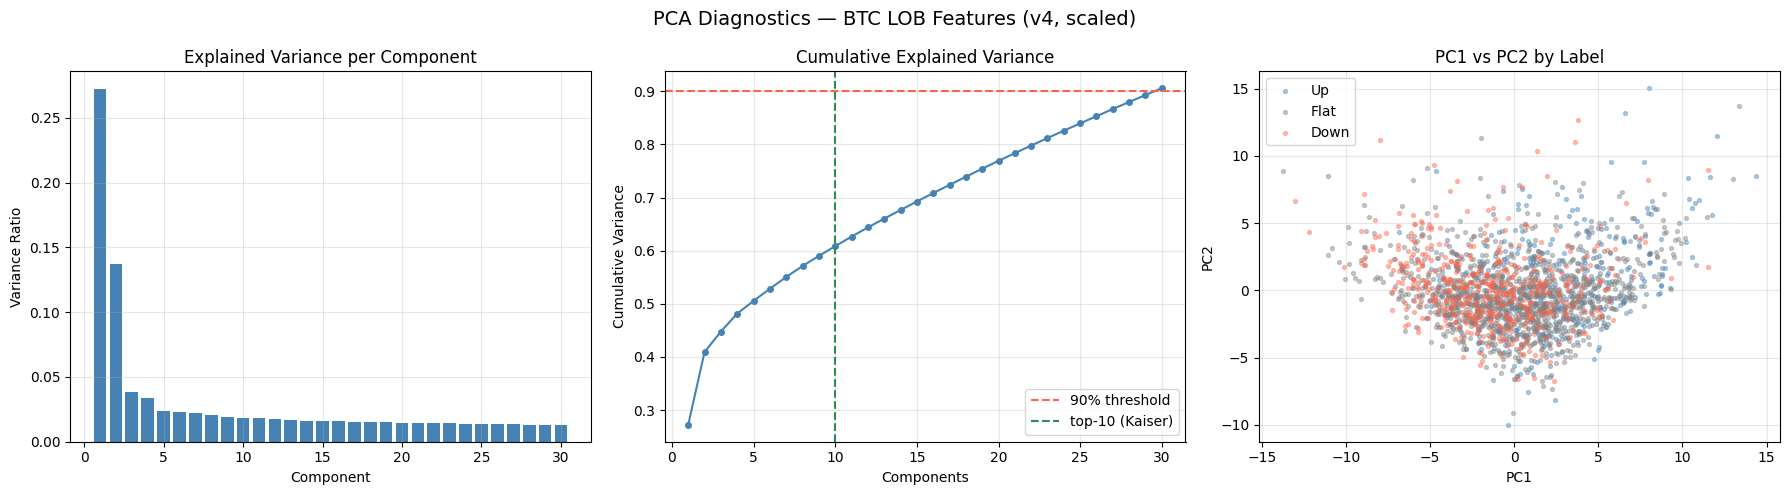

In [7]:
# ==========================================
# 7. PCA Diagnostics
# ==========================================
print("\n" + "=" * 50)
print("7. PCA DIAGNOSTICS")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PCA Diagnostics — BTC LOB Features (v4, scaled)", fontsize=14)

axes[0].bar(range(1, pca.n_components_ + 1),
            pca.explained_variance_ratio_, color='steelblue')
axes[0].set_title("Explained Variance per Component")
axes[0].set_xlabel("Component"); axes[0].set_ylabel("Variance Ratio")
axes[0].grid(alpha=0.3)

cum = pca.explained_variance_ratio_.cumsum()
axes[1].plot(range(1, pca.n_components_ + 1), cum,
             color='steelblue', marker='o', ms=4)
axes[1].axhline(0.90, color='tomato', linestyle='--', label='90% threshold')
axes[1].axvline(top_n_pca, color='seagreen', linestyle='--',
                label=f'top-{top_n_pca} (Kaiser)')
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Components"); axes[1].set_ylabel("Cumulative Variance")
axes[1].legend(); axes[1].grid(alpha=0.3)

idx     = np.random.choice(len(X_train_pca), min(2000, len(X_train_pca)), replace=False)
y_train = df['label'].iloc[:split_idx]
for lbl, color, name in [(1, 'steelblue', 'Up'), (0, 'gray', 'Flat'), (-1, 'tomato', 'Down')]:
    mask = y_train.iloc[idx] == lbl
    axes[2].scatter(X_train_pca[idx][mask, 0], X_train_pca[idx][mask, 1],
                    c=color, alpha=0.4, s=8, label=name)
axes[2].set_title("PC1 vs PC2 by Label")
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
# ==========================================
# 8. Final Dataset Assembly & Export
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

print("\n" + "=" * 50)
print("8. EXPORT DATASETS (v4)")
print("=" * 50)

save_path = '/content/drive/MyDrive/629/'

# ── PCA: keep top-N components (Kaiser, capped at 10) ─────────
pca_cols_all  = [f'pca_{i+1}' for i in range(pca.n_components_)]
pca_cols_topn = [f'pca_{i+1}' for i in range(top_n_pca)]

pca_df_full = pd.DataFrame(
    np.vstack((X_train_pca, X_test_pca)),
    columns=pca_cols_all,
    index=df.index
)
pca_df = pca_df_full[pca_cols_topn]

# ── Common meta columns ───────────────────────────────────────
common_cols = pd.DataFrame({
    'label':         df['label'].values,
    'future_return': df['future_return'].values,
    'split':         ['train'] * split_idx + ['test'] * (len(df) - split_idx)
}, index=df.index)

# ── Dataset A: Full (PCA top-N + Market + Classic) ────────────
# v4: market and classic are now rolling-Z-scored (same scale as PCA)
df_full = pd.concat([pca_df,
                     df[market_state_cols],
                     df[classic_factor_cols],
                     common_cols], axis=1)
df_full.to_csv(save_path + 'lob_full_v4.csv', index=False)
print(f"Saved lob_full_v4.csv       | Shape: {df_full.shape}")
print(f"  = PCA({top_n_pca}) + market({len(market_state_cols)}) "
      f"+ classic({len(classic_factor_cols)}) + meta(3)")

# ── Dataset B: No PCA (Raw Z-scored LOB + Market + Classic) ───
df_no_pca = pd.concat([df[lob_features],
                        df[market_state_cols],
                        df[classic_factor_cols],
                        common_cols], axis=1)
df_no_pca.to_csv(save_path + 'lob_no_pca_v4.csv', index=False)
print(f"Saved lob_no_pca_v4.csv     | Shape: {df_no_pca.shape}")
print(f"  = raw_LOB({len(lob_features)}) + market({len(market_state_cols)}) "
      f"+ classic({len(classic_factor_cols)}) + meta(3)")

# ── Dataset C: No Market (PCA top-N + Classic only) ───────────
df_no_market = pd.concat([pca_df,
                           df[classic_factor_cols],
                           common_cols], axis=1)
df_no_market.to_csv(save_path + 'lob_no_market_v4.csv', index=False)
print(f"Saved lob_no_market_v4.csv  | Shape: {df_no_market.shape}")
print(f"  = PCA({top_n_pca}) + classic({len(classic_factor_cols)}) + meta(3)")

print("\n--- Feature scale verification on exported data ---")
for name, dset, cols in [
    ("Full    — market", df_full,      market_state_cols[:3]),
    ("Full    — classic", df_full,     classic_factor_cols[:3]),
    ("No PCA  — LOB",    df_no_pca,    lob_features[:3]),
    ("No Mkt  — classic", df_no_market, classic_factor_cols[:3]),
]:
    m = dset[cols].mean().mean()
    s = dset[cols].std().mean()
    print(f"  {name:<25} mean={m:+.4f}  std={s:.4f}")

print("\nAll feature groups now exported at consistent ~N(0,1) scale.")
print("Pipeline v4 complete.")


Mounted at /content/drive

8. EXPORT DATASETS (v4)
Saved lob_full_v4.csv       | Shape: (99783, 41)
  = PCA(10) + market(15) + classic(13) + meta(3)
Saved lob_no_pca_v4.csv     | Shape: (99783, 91)
  = raw_LOB(60) + market(15) + classic(13) + meta(3)
Saved lob_no_market_v4.csv  | Shape: (99783, 26)
  = PCA(10) + classic(13) + meta(3)

--- Feature scale verification on exported data ---
  Full    — market          mean=-0.0093  std=1.0125
  Full    — classic         mean=+0.0013  std=1.0064
  No PCA  — LOB             mean=+0.0115  std=1.0355
  No Mkt  — classic         mean=+0.0013  std=1.0064

All feature groups now exported at consistent ~N(0,1) scale.
Pipeline v4 complete.
